# Прогнозирование погоды с помощью нейронных сетей

Чтобы запускать и редактировать код, сохраните копию этого ноутбука себе (Файл -> Создать копию на Диске). Свою копию вы сможете изменять и запускать.

Учебный курс "[Программирование глубоких нейронных сетей на Python](https://openedu.ru/course/urfu/PYDNN/)".

За основу взят [ноутбук по анализу временных рядов из книги Deel Learning With Python](https://github.com/fchollet/deep-learning-with-python-notebooks/blob/master/chapter13_timeseries-forecasting.ipynb).

<a target="_blank" href="https://colab.research.google.com/github/sozykin/dlpython_course/blob/master/timeseries/weather_tensorflow.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

In [1]:
import numpy as np
import zipfile
import os
import matplotlib.pyplot as plt
from pathlib import Path
from tensorflow import keras
from tensorflow.keras import layers
%matplotlib inline

## Загружаем данные

In [2]:
data_path = 'data'

In [3]:
path = Path(data_path)

if not path.exists():
    path.mkdir(parents=True, exist_ok=True)

In [4]:
!curl -s -L -o data/jena_climate_2009_2016.csv.zip "https://s3.amazonaws.com/keras-datasets/jena_climate_2009_2016.csv.zip"

In [5]:
with zipfile.ZipFile("data/jena_climate_2009_2016.csv.zip", 'r') as zip_ref:
    zip_ref.extractall(data_path)

In [6]:
fname = os.path.join("data/jena_climate_2009_2016.csv")

with open(fname) as f:
    data = f.read()

lines = data.split("\n")
header = lines[0].split(",")
lines = lines[1:]
print(header)
print(len(lines))

['"Date Time"', '"p (mbar)"', '"T (degC)"', '"Tpot (K)"', '"Tdew (degC)"', '"rh (%)"', '"VPmax (mbar)"', '"VPact (mbar)"', '"VPdef (mbar)"', '"sh (g/kg)"', '"H2OC (mmol/mol)"', '"rho (g/m**3)"', '"wv (m/s)"', '"max. wv (m/s)"', '"wd (deg)"']
420451


## Готовим данные

Извлекаем данные о температуре

In [7]:
temperature = np.zeros((len(lines),))
raw_data = np.zeros((len(lines), len(header) - 1))

for i, line in enumerate(lines):
    values = [float(x) for x in line.split(",")[1:]]
    temperature[i] = values[1]
    raw_data[i, :] = values[:]

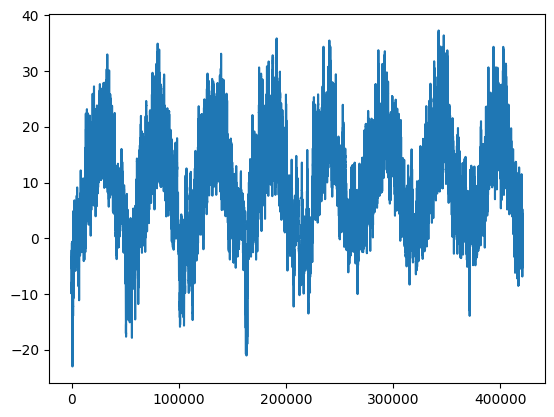

In [8]:
plt.plot(range(len(temperature)), temperature)

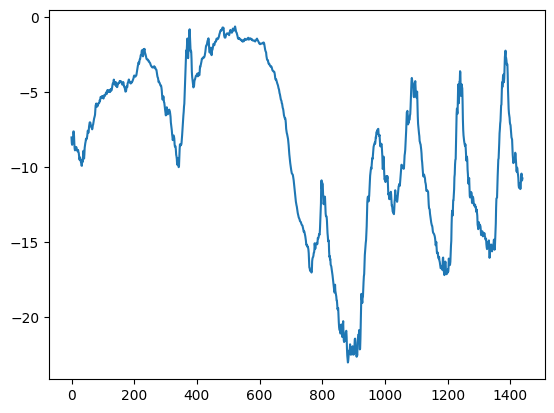

In [9]:
plt.plot(range(1440), temperature[:1440])

Разбиваем данные на обучающий, проверочный и тестовый наборы

In [10]:
num_train_samples = int(0.5 * len(raw_data))
num_val_samples = int(0.25 * len(raw_data))
num_test_samples = len(raw_data) - num_train_samples - num_val_samples
print("Количество измерений в обучающем наборе:", num_train_samples)
print("Количество измерений в проверочном наборе:", num_val_samples)
print("Количество измерений в тестовом наборе:", num_test_samples)

Количество измерений в обучающем наборе: 210225
Количество измерений в проверочном наборе: 105112
Количество измерений в тестовом наборе: 105114


Нормализуем данные

In [11]:
mean = raw_data[:num_train_samples].mean(axis=0)
raw_data -= mean
std = raw_data[:num_train_samples].std(axis=0)
raw_data /= std

## Создаем Dataset для TensorFlow

Пример работы timeseries_dataset_from_array

In [12]:
int_sequence = np.arange(10)
dummy_dataset = keras.utils.timeseries_dataset_from_array(
    data=int_sequence[:-3],
    targets=int_sequence[3:],
    sequence_length=3,
    batch_size=2,
)

for inputs, targets in dummy_dataset:
    for i in range(inputs.shape[0]):
        print([int(x) for x in inputs[i]], int(targets[i]))

[0, 1, 2] 3
[1, 2, 3] 4
[2, 3, 4] 5
[3, 4, 5] 6
[4, 5, 6] 7


In [13]:
sampling_rate = 6
sequence_length = 120
delay = sampling_rate * (sequence_length + 24 - 1)
batch_size = 256

train_dataset = keras.utils.timeseries_dataset_from_array(
    raw_data[:-delay],
    targets=temperature[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size,
    start_index=0,
    end_index=num_train_samples,
)

val_dataset = keras.utils.timeseries_dataset_from_array(
    raw_data[:-delay],
    targets=temperature[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size,
    start_index=num_train_samples,
    end_index=num_train_samples + num_val_samples,
)

test_dataset = keras.utils.timeseries_dataset_from_array(
    raw_data[:-delay],
    targets=temperature[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size,
    start_index=num_train_samples + num_val_samples,
)

In [14]:
for samples, targets in train_dataset:
    print("Размерность обучающей мини-выборки:", samples.shape)
    print("Размерность целевой переменной:", targets.shape)
    break

Размерность обучающей мини-выборки: (256, 120, 14)
Размерность целевой переменной: (256,)


## Создаем базовое решение

Всегда предстказываем последнее значение

In [15]:
def evaluate_naive_method(dataset):
    total_abs_err = 0.0
    samples_seen = 0
    for samples, targets in dataset:
        preds = samples[:, -1, 1] * std[1] + mean[1]
        total_abs_err += np.sum(np.abs(preds - targets))
        samples_seen += samples.shape[0]
    return total_abs_err / samples_seen

print(f"Validation MAE: {evaluate_naive_method(val_dataset):.2f}")
print(f"Test MAE: {evaluate_naive_method(test_dataset):.2f}")

Validation MAE: 2.44
Test MAE: 2.62


## Полносвязная нейронная сеть

In [16]:
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.Flatten()(inputs)
x = layers.Dense(16, activation="relu")(x)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint("jena_dense.keras", save_best_only=True)
]
model.compile(optimizer="adam", loss="mse", metrics=["mae"])
history = model.fit(
    train_dataset,
    epochs=10,
    validation_data=val_dataset,
    callbacks=callbacks,
)

model = keras.models.load_model("jena_dense.keras")
print(f"Test MAE: {model.evaluate(test_dataset)[1]:.2f}")

Epoch 1/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - loss: 12.5288 - mae: 2.7081 - val_loss: 10.5411 - val_mae: 2.5603
Epoch 2/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - loss: 8.1503 - mae: 2.2468 - val_loss: 10.3002 - val_mae: 2.5255
Epoch 3/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 7.4315 - mae: 2.1440 - val_loss: 10.8075 - val_mae: 2.5878
Epoch 4/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 6.9981 - mae: 2.0802 - val_loss: 11.3202 - val_mae: 2.6470
Epoch 5/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - loss: 6.6883 - mae: 2.0345 - val_loss: 11.1312 - val_mae: 2.6149
Epoch 6/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - loss: 6.4698 - mae: 2.0005 - val_loss: 11.4230 - val_mae: 2.6432
Epoch 7/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 6.3162 - mae: 1.9782 - val_loss: 11.6232 - val_mae: 2.6658
Epoch 8/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 6.1750 - mae: 1.9550 - val_loss: 11.8739 - val_mae: 2.6925
Epoch 9/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 8s 

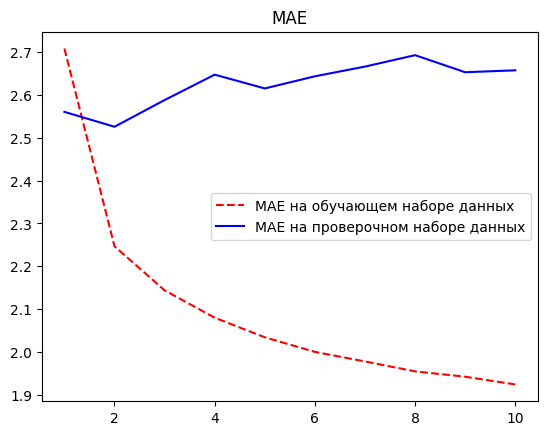

In [17]:
loss = history.history["mae"]
val_loss = history.history["val_mae"]
epochs = range(1, len(loss) + 1)
plt.figure()
plt.plot(epochs, loss, "r--", label="MAE на обучающем наборе данных")
plt.plot(epochs, val_loss, "b", label="MAE на проверочном наборе данных")
plt.title("MAE")
plt.legend()
plt.show()

## Одномерная сверточная нейронная сеть

In [ ]:
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.Conv1D(8, 24, activation="relu")(inputs)
x = layers.MaxPooling1D(2)(x)
x = layers.Conv1D(8, 12, activation="relu")(x)
x = layers.MaxPooling1D(2)(x)
x = layers.Conv1D(8, 6, activation="relu")(x)
x = layers.GlobalAveragePooling1D()(x)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint("jena_conv.keras", save_best_only=True)
]
model.compile(optimizer="adam", loss="mse", metrics=["mae"])
history = model.fit(
    train_dataset,
    epochs=10,
    validation_data=val_dataset,
    callbacks=callbacks,
)

model = keras.models.load_model("jena_conv.keras")

Epoch 1/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - loss: 23.3232 - mae: 3.7171 - val_loss: 14.5211 - val_mae: 3.0230
Epoch 2/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 13.9216 - mae: 2.9562 - val_loss: 14.9419 - val_mae: 3.0684
Epoch 3/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 12.6175 - mae: 2.8095 - val_loss: 15.1056 - val_mae: 3.0766
Epoch 4/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 11.7456 - mae: 2.7084 - val_loss: 16.2942 - val_mae: 3.1957
Epoch 5/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 11.0347 - mae: 2.6212 - val_loss: 15.2246 - val_mae: 3.0832
Epoch 6/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 10.4806 - mae: 2.5527 - val_loss: 15.6055 - val_mae: 3.1175
Epoch 7/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 10.0236 - mae: 2.4934 - val_loss: 15.9853 - val_mae: 3.1567
Epoch 8/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - loss: 9.6397 - mae: 2.4428 - val_loss: 15.8158 - val_mae: 3.1338
Epoch 9/10
819/819 ━━━━━━

In [ ]:
print(f"MAE на тестовом наборе данных: {model.evaluate(test_dataset)[1]:.2f}")

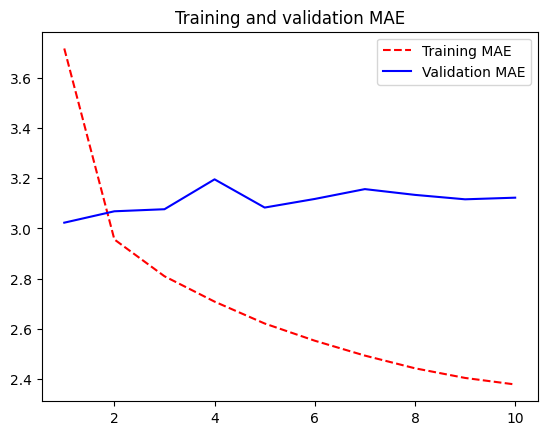

In [19]:
loss = history.history["mae"]
val_loss = history.history["val_mae"]
epochs = range(1, len(loss) + 1)
plt.figure()
plt.plot(epochs, loss, "r--", label="Training MAE")
plt.plot(epochs, val_loss, "b", label="Validation MAE")
plt.title("Training and validation MAE")
plt.legend()
plt.show()

## Сеть LSTM

In [20]:
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.LSTM(16)(inputs)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint("jena_lstm.keras", save_best_only=True)
]
model.compile(optimizer="adam", loss="mse", metrics=["mae"])
history = model.fit(
    train_dataset,
    epochs=10,
    validation_data=val_dataset,
    callbacks=callbacks,
)

model = keras.models.load_model("jena_lstm.keras")


Epoch 1/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 30s 35ms/step - loss: 45.6711 - mae: 4.9930 - val_loss: 17.5394 - val_mae: 3.1277
Epoch 2/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 29s 35ms/step - loss: 14.7828 - mae: 2.9189 - val_loss: 11.3202 - val_mae: 2.5758
Epoch 3/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 33s 40ms/step - loss: 11.1644 - mae: 2.5847 - val_loss: 10.2275 - val_mae: 2.4612
Epoch 4/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 34s 42ms/step - loss: 9.8561 - mae: 2.4425 - val_loss: 9.7223 - val_mae: 2.4162
Epoch 5/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 34s 42ms/step - loss: 9.3132 - mae: 2.3760 - val_loss: 9.8468 - val_mae: 2.4301
Epoch 6/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 34s 41ms/step - loss: 8.8579 - mae: 2.3215 - val_loss: 9.8133 - val_mae: 2.4252
Epoch 7/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 35s 42ms/step - loss: 8.5809 - mae: 2.2835 - val_loss: 9.7835 - val_mae: 2.4126
Epoch 8/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 40s 49ms/step - loss: 8.2911 - mae: 2.2518 - val_loss: 9.9565 - val_mae: 2.4336
Epoch 9/10
819/819 ━━━━━━━━━━━━━━━

In [21]:
print(f"MAE на тестовом наборе данных: {model.evaluate(test_dataset)[1]:.2f}")

405/405 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - loss: 11.2940 - mae: 2.6346
MAE на тестовом наборе данных: 2.63


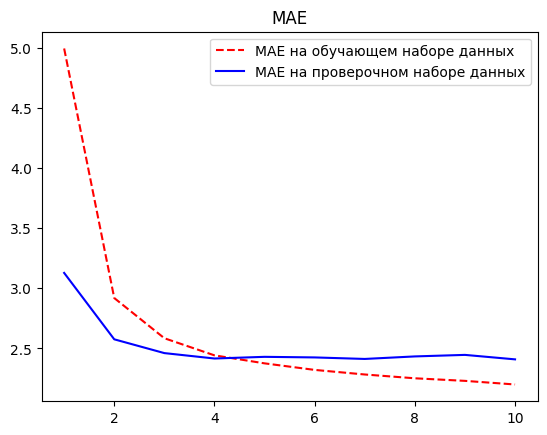

In [22]:
loss = history.history["mae"]
val_loss = history.history["val_mae"]
epochs = range(1, len(loss) + 1)
plt.figure()
plt.plot(epochs, loss, "r--", label="MAE на обучающем наборе данных")
plt.plot(epochs, val_loss, "b", label="MAE на проверочном наборе данных")
plt.title("MAE")
plt.legend()
plt.show()

Используем Dropout для снижения переобучения

In [23]:
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.LSTM(32, recurrent_dropout=0.25)(inputs)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint(
        "jena_lstm_dropout.keras", save_best_only=True
    )
]
model.compile(optimizer="adam", loss="mse", metrics=["mae"])
history = model.fit(
    train_dataset,
    epochs=20,
    validation_data=val_dataset,
    callbacks=callbacks,
)

Epoch 1/20
819/819 ━━━━━━━━━━━━━━━━━━━━ 56s 66ms/step - loss: 32.9161 - mae: 4.2369 - val_loss: 11.2363 - val_mae: 2.5645
Epoch 2/20
819/819 ━━━━━━━━━━━━━━━━━━━━ 55s 67ms/step - loss: 16.2395 - mae: 3.1265 - val_loss: 9.5386 - val_mae: 2.3930
Epoch 3/20
819/819 ━━━━━━━━━━━━━━━━━━━━ 52s 64ms/step - loss: 15.1597 - mae: 3.0224 - val_loss: 9.1855 - val_mae: 2.3547
Epoch 4/20
819/819 ━━━━━━━━━━━━━━━━━━━━ 48s 58ms/step - loss: 14.6265 - mae: 2.9682 - val_loss: 8.9797 - val_mae: 2.3273
Epoch 5/20
819/819 ━━━━━━━━━━━━━━━━━━━━ 49s 60ms/step - loss: 14.1043 - mae: 2.9128 - val_loss: 8.8285 - val_mae: 2.3061
Epoch 6/20
819/819 ━━━━━━━━━━━━━━━━━━━━ 48s 59ms/step - loss: 13.7517 - mae: 2.8803 - val_loss: 8.6911 - val_mae: 2.2856
Epoch 7/20
819/819 ━━━━━━━━━━━━━━━━━━━━ 51s 63ms/step - loss: 13.3432 - mae: 2.8320 - val_loss: 8.7643 - val_mae: 2.2958
Epoch 8/20
819/819 ━━━━━━━━━━━━━━━━━━━━ 47s 57ms/step - loss: 13.1330 - mae: 2.8060 - val_loss: 8.7648 - val_mae: 2.2997
Epoch 9/20
819/819 ━━━━━━━━━━━━

In [24]:
print(f"MAE на тестовом наборе данных: {model.evaluate(test_dataset)[1]:.2f}")

405/405 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - loss: 9.9203 - mae: 2.4912
MAE на тестовом наборе данных: 2.49


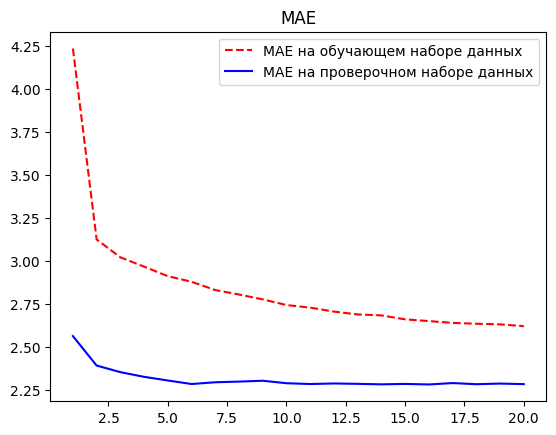

In [25]:
loss = history.history["mae"]
val_loss = history.history["val_mae"]
epochs = range(1, len(loss) + 1)
plt.figure()
plt.plot(epochs, loss, "r--", label="MAE на обучающем наборе данных")
plt.plot(epochs, val_loss, "b", label="MAE на проверочном наборе данных")
plt.title("MAE")
plt.legend()
plt.show()

## Несколько рекуррентных слоев

In [26]:
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.GRU(32, recurrent_dropout=0.5, return_sequences=True)(inputs)
x = layers.GRU(32, recurrent_dropout=0.5)(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint(
        "jena_stacked_gru_dropout.keras", save_best_only=True
    )
]
model.compile(optimizer="adam", loss="mse", metrics=["mae"])
history = model.fit(
    train_dataset,
    epochs=20,
    validation_data=val_dataset,
    callbacks=callbacks,
)
model = keras.models.load_model("jena_stacked_gru_dropout.keras")

Epoch 1/20
819/819 ━━━━━━━━━━━━━━━━━━━━ 111s 130ms/step - loss: 28.6661 - mae: 3.9621 - val_loss: 10.6977 - val_mae: 2.4794
Epoch 2/20
819/819 ━━━━━━━━━━━━━━━━━━━━ 97s 118ms/step - loss: 15.1108 - mae: 3.0013 - val_loss: 9.2490 - val_mae: 2.3439
Epoch 3/20
819/819 ━━━━━━━━━━━━━━━━━━━━ 99s 121ms/step - loss: 14.0062 - mae: 2.8941 - val_loss: 8.7698 - val_mae: 2.2890
Epoch 4/20
819/819 ━━━━━━━━━━━━━━━━━━━━ 100s 123ms/step - loss: 13.5777 - mae: 2.8510 - val_loss: 8.6615 - val_mae: 2.2775
Epoch 5/20
819/819 ━━━━━━━━━━━━━━━━━━━━ 105s 129ms/step - loss: 13.0630 - mae: 2.7976 - val_loss: 8.5916 - val_mae: 2.2686
Epoch 6/20
819/819 ━━━━━━━━━━━━━━━━━━━━ 108s 132ms/step - loss: 12.6715 - mae: 2.7557 - val_loss: 8.5534 - val_mae: 2.2674
Epoch 7/20
819/819 ━━━━━━━━━━━━━━━━━━━━ 812s 992ms/step - loss: 12.2428 - mae: 2.7114 - val_loss: 8.5947 - val_mae: 2.2740
Epoch 8/20
819/819 ━━━━━━━━━━━━━━━━━━━━ 106s 129ms/step - loss: 11.9518 - mae: 2.6792 - val_loss: 8.5426 - val_mae: 2.2687
Epoch 9/20
819/81

In [27]:
print(f"MAE на тестовом наборе данных: {model.evaluate(test_dataset)[1]:.2f}")

405/405 ━━━━━━━━━━━━━━━━━━━━ 17s 40ms/step - loss: 9.3293 - mae: 2.3916
MAE на тестовом наборе данных: 2.39


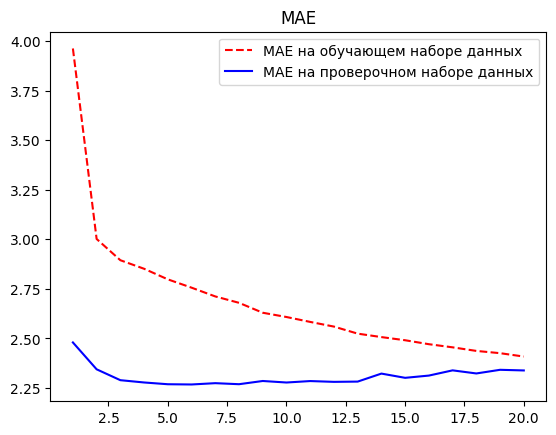

In [28]:
loss = history.history["mae"]
val_loss = history.history["val_mae"]
epochs = range(1, len(loss) + 1)
plt.figure()
plt.plot(epochs, loss, "r--", label="MAE на обучающем наборе данных")
plt.plot(epochs, val_loss, "b", label="MAE на проверочном наборе данных")
plt.title("MAE")
plt.legend()
plt.show()

## Используем двунаправленную рекуррентную сеть

In [32]:
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.Bidirectional(layers.LSTM(16))(inputs)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint(
        "jena_bidirectional_lstm.keras", save_best_only=True
    )
]

model.compile(optimizer="adam", loss="mse", metrics=["mae"])
history = model.fit(
    train_dataset,
    epochs=10,
    validation_data=val_dataset,
    callbacks=callbacks,
)

model = keras.models.load_model("jena_bidirectional_lstm.keras")

Epoch 1/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 44s 51ms/step - loss: 31.3958 - mae: 4.0709 - val_loss: 12.8610 - val_mae: 2.7671
Epoch 2/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 47s 58ms/step - loss: 11.5925 - mae: 2.6599 - val_loss: 11.1580 - val_mae: 2.5932
Epoch 3/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 48s 58ms/step - loss: 9.7972 - mae: 2.4406 - val_loss: 10.7074 - val_mae: 2.5279
Epoch 4/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 48s 59ms/step - loss: 8.9828 - mae: 2.3333 - val_loss: 9.8394 - val_mae: 2.4129
Epoch 5/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 47s 57ms/step - loss: 8.4983 - mae: 2.2692 - val_loss: 9.7015 - val_mae: 2.4026
Epoch 6/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 46s 56ms/step - loss: 7.9882 - mae: 2.1993 - val_loss: 9.9579 - val_mae: 2.4354
Epoch 7/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 50s 61ms/step - loss: 7.6612 - mae: 2.1549 - val_loss: 9.9230 - val_mae: 2.4287
Epoch 8/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 48s 59ms/step - loss: 7.2497 - mae: 2.0998 - val_loss: 10.2680 - val_mae: 2.4659
Epoch 9/10
819/819 ━━━━━━━━━━━━━━━

In [33]:
print(f"MAE на тестовом наборе данных: {model.evaluate(test_dataset)[1]:.2f}")

405/405 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - loss: 10.3745 - mae: 2.5290
MAE на тестовом наборе данных: 2.53


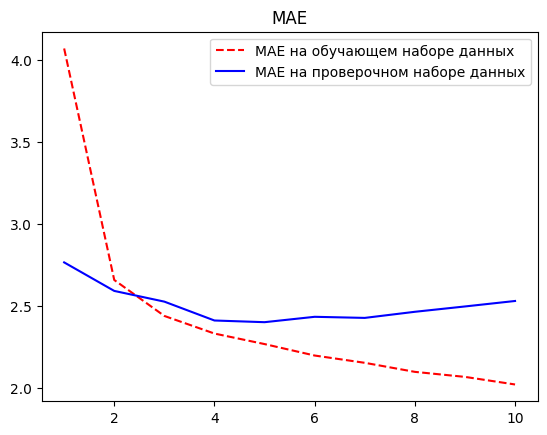

In [34]:
loss = history.history["mae"]
val_loss = history.history["val_mae"]
epochs = range(1, len(loss) + 1)
plt.figure()
plt.plot(epochs, loss, "r--", label="MAE на обучающем наборе данных")
plt.plot(epochs, val_loss, "b", label="MAE на проверочном наборе данных")
plt.title("MAE")
plt.legend()
plt.show()